# **🧠 Mental Health Risk Prediction (ML)**
### **Can we predict if someone is at High / Moderate / Low mental health risk?**

In this notebook, we will:
1. **Explore** the dataset (EDA)
2. **Preprocess** the data (encode categories, scale numbers)
3. **Train** multiple ML models
4. **Evaluate** and pick the best one
5. **Conclude** with key findings

> **Dataset:** 300,000 survey responses with lifestyle & psychological features.


## **📦 Step 1 — Import Libraries**
We bring in all the tools we need upfront.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

# Makes plots look nicer
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
print("✅ Libraries loaded!")


✅ Libraries loaded!


## **📂 Step 2 — Load the Dataset**
We load the CSV and take a first look.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mirzayasirabdullah07/300k-mental-health-survey-dataset/mental_health_survey_dataset_300k.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (300000, 20)


,participant_id,age,gender,country,occupation,work_hours_per_week,screen_time_hours,sleep_hours,sleep_quality,exercise_frequency,stress_score,anxiety_score,depression_score,social_support,therapy_history,family_history_mental_illness,academic_or_job_pressure,financial_stress_score,mental_health_risk,survey_date
0,5d5158c6-7eea-4ed8-bb28-5afb07836137,58,Female,Canada,Teacher,23,9.8,9.2,Poor,Regularly,2,1,5,Weak,Yes,Yes,4,4,Moderate,2025-08-05
1,518dc525-f8d3-4775-bdbe-d46ef078b37b,50,Female,Saudi Arabia,Data Scientist,38,6.8,4.9,Poor,Rarely,10,1,9,Strong,No,No,5,3,High,2026-03-20
2,30118b61-bd27-4e4b-b215-3f146f1de820,31,Prefer not to say,India,Freelancer,54,8.8,8.6,Excellent,Never,6,2,2,Moderate,Yes,No,10,6,Moderate,2025-08-06
3,25ad1e03-6b10-4d0c-a84e-366768e158aa,54,Female,UK,Software Engineer,39,12.3,5.7,Excellent,Sometimes,4,2,1,Weak,No,No,4,5,Low,2025-11-10
4,4126273e-5507-4869-bc90-3ae6104f0cf8,59,Female,USA,Manager,58,4.5,9.5,Average,Sometimes,2,10,3,Weak,Yes,Yes,6,7,High,2026-02-11


In [3]:
# Quick info
print(df.dtypes)
print("\nMissing values:", df.isnull().sum().sum())


participant_id                    object
age                                int64
gender                            object
country                           object
occupation                        object
work_hours_per_week                int64
screen_time_hours                float64
sleep_hours                      float64
sleep_quality                     object
exercise_frequency                object
stress_score                       int64
anxiety_score                      int64
depression_score                   int64
social_support                    object
therapy_history                   object
family_history_mental_illness     object
academic_or_job_pressure           int64
financial_stress_score             int64
mental_health_risk                object
survey_date                       object
dtype: object

Missing values: 0


## **🔍 Step 3 — Exploratory Data Analysis (EDA)**
Let's understand our data visually before building any model.

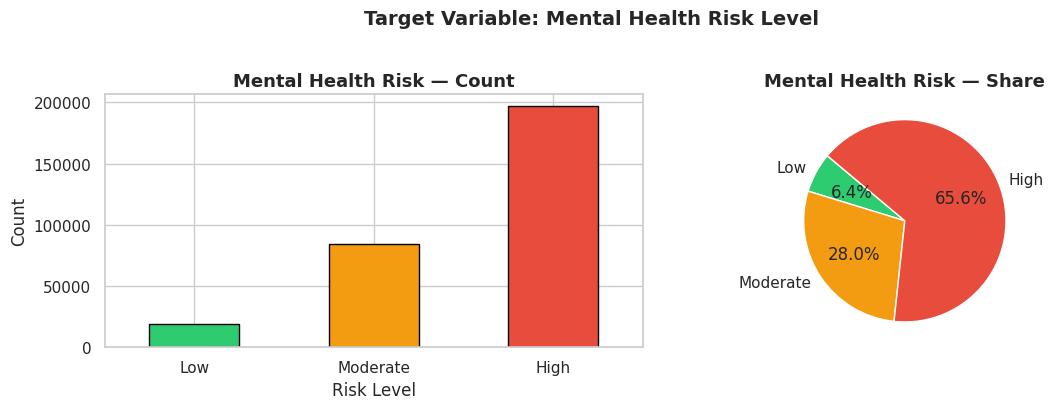

mental_health_risk
High        196752
Moderate     84114
Low          19134
Name: count, dtype: int64


In [4]:
# ── 3a. Target variable distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order = ['Low', 'Moderate', 'High']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

# Count plot
df['mental_health_risk'].value_counts().reindex(order).plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Mental Health Risk — Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk Level'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['mental_health_risk'].value_counts().reindex(order).plot(
    kind='pie', ax=axes[1], colors=colors, autopct='%1.1f%%',
    startangle=140, labels=order)
axes[1].set_title('Mental Health Risk — Share', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Target Variable: Mental Health Risk Level', fontsize=14, y=1.02,fontweight='bold')
plt.tight_layout()
plt.show()

print(df['mental_health_risk'].value_counts())


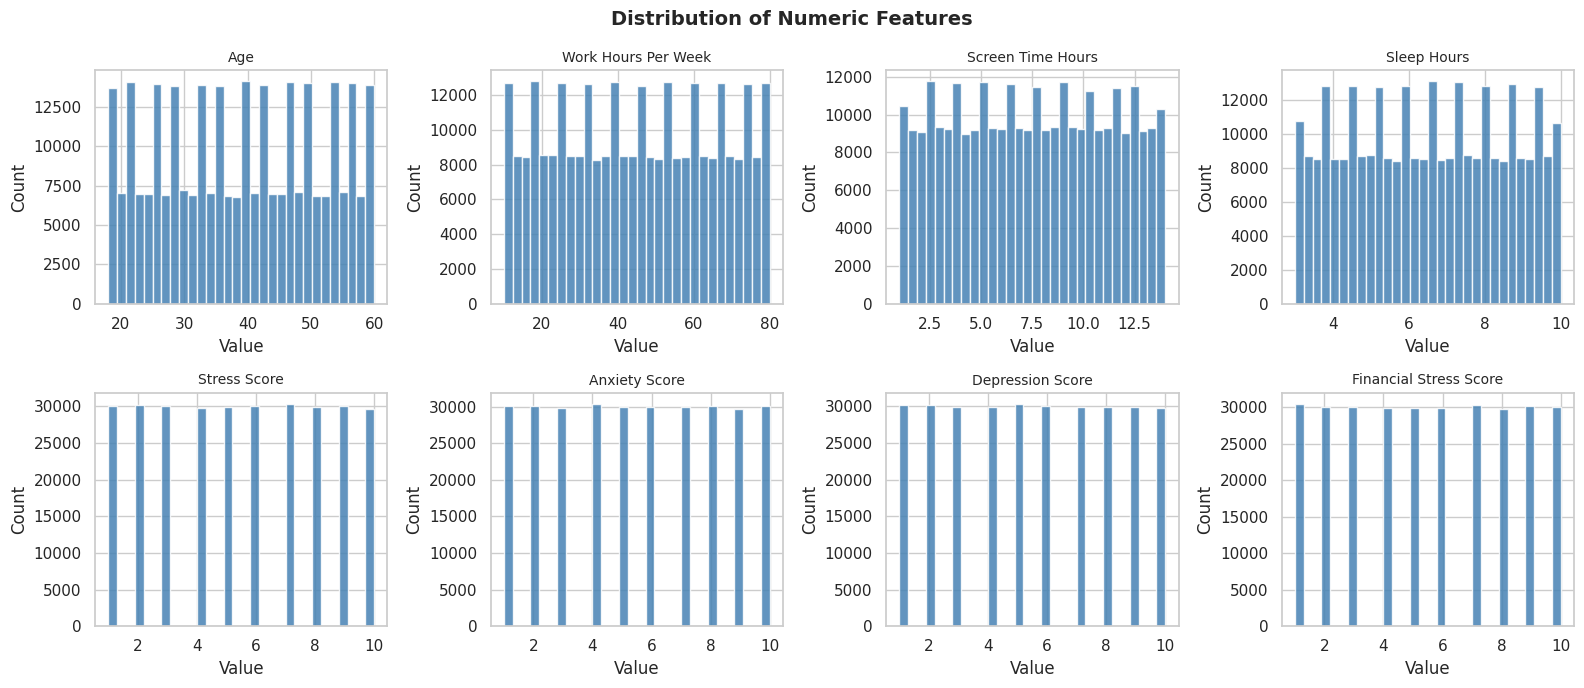

In [5]:
# ── 3b. Numeric feature distributions ─────────────────────────────────────
num_cols = ['age', 'work_hours_per_week', 'screen_time_hours',
            'sleep_hours', 'stress_score', 'anxiety_score',
            'depression_score', 'financial_stress_score']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    axes[i].set_xlabel('Value'); axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


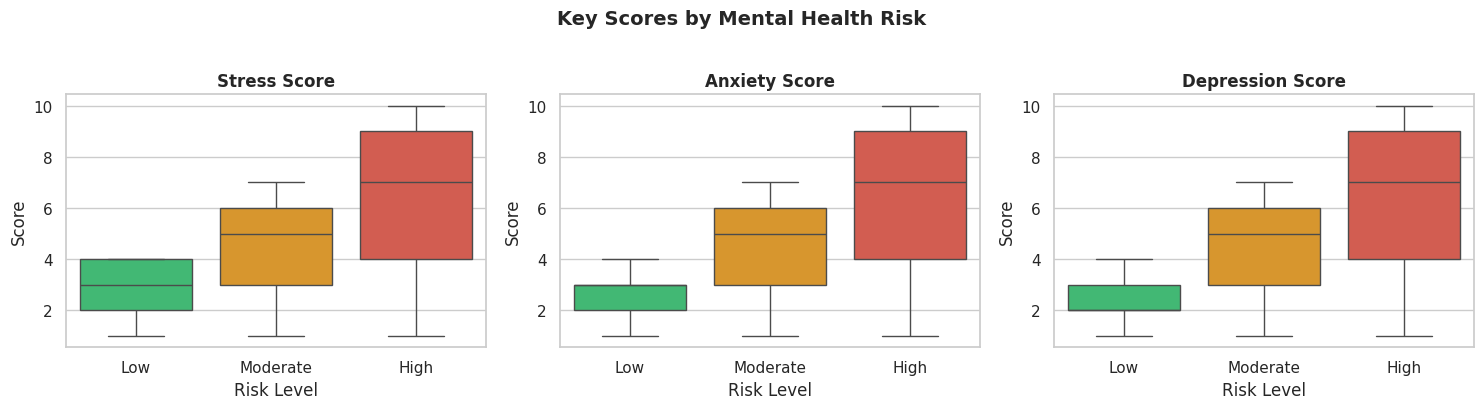

In [6]:
# ── 3c. Stress / Anxiety / Depression vs Risk ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
score_cols = ['stress_score', 'anxiety_score', 'depression_score']

for ax, col in zip(axes, score_cols):
    sns.boxplot(data=df, x='mental_health_risk', y=col,
                order=['Low', 'Moderate', 'High'],
                palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=ax)
    ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Risk Level'); ax.set_ylabel('Score')

plt.suptitle('Key Scores by Mental Health Risk', fontsize=14, y=1.02,fontweight='bold')
plt.tight_layout()
plt.show()


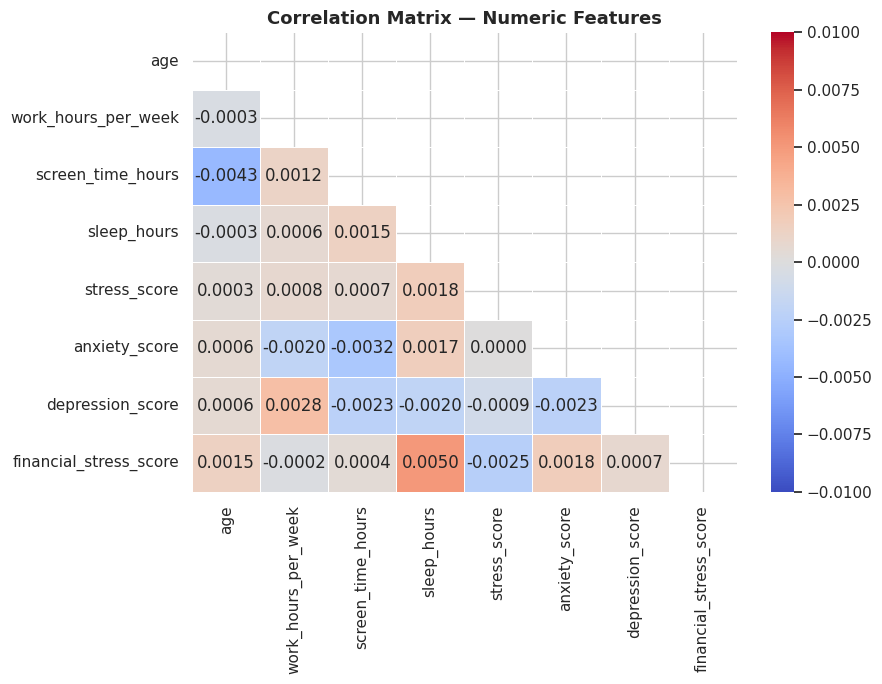

In [7]:
# ── 3d. Correlation heat-map (numeric only) ────────────────────────────────
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=int))
sns.heatmap(corr, mask=mask, annot=True, fmt='.4f', cmap='coolwarm',
            linewidths=0.5, vmin=-0.01,vmax=0.01)
plt.title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## **🛠️ Step 4 — Data Preprocessing**
Before feeding data to a model we need to:
- **Encode** text columns → numbers
- **Drop** columns not useful for prediction
- **Scale** numeric features so every feature is on the same scale


In [8]:
# ── 4a. Drop unnecessary columns ──────────────────────────────────────────
df_model = df.drop(columns=['participant_id', 'survey_date', 'country'])

# ── 4b. Encode categorical columns ────────────────────────────────────────
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols.remove('mental_health_risk')          # keep target separate

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Encode target
risk_map = {'Low': 0, 'Moderate': 1, 'High': 2}
df_model['mental_health_risk'] = df_model['mental_health_risk'].map(risk_map)

print("Encoded categories:", cat_cols)
df_model.head(3)


Encoded categories: ['gender', 'occupation', 'sleep_quality', 'exercise_frequency', 'social_support', 'therapy_history', 'family_history_mental_illness']


,age,gender,occupation,work_hours_per_week,screen_time_hours,sleep_hours,sleep_quality,exercise_frequency,stress_score,anxiety_score,depression_score,social_support,therapy_history,family_history_mental_illness,academic_or_job_pressure,financial_stress_score,mental_health_risk
0,58,0,8,23,9.8,9.2,3,2,2,1,5,2,1,1,4,4,1
1,50,0,0,38,6.8,4.9,3,1,10,1,9,1,0,0,5,3,2
2,31,3,3,54,8.8,8.6,1,0,6,2,2,0,1,0,10,6,1


In [9]:
# ── 4c. Features & target ─────────────────────────────────────────────────
X = df_model.drop(columns=['mental_health_risk'])
y = df_model['mental_health_risk']

# ── 4d. Train / Test split (80 / 20) ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Train size : {X_train.shape[0]:,}")
print(f"Test  size : {X_test.shape[0]:,}")


Train size : 240,000
Test  size : 60,000


In [10]:
# ── 4e. Scale numeric features ────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("✅ Scaling done!")


✅ Scaling done!


## **🤖 Step 5 — Train ML Models**
We try **3 models** and compare them:
| Model | Why? |
|---|---|
| Logistic Regression | Simple, fast baseline |
| Random Forest | Powerful ensemble, handles non-linearity |
| Gradient Boosting | Often state-of-the-art on tabular data |


In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                                   random_state=42),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200,
                                                       learning_rate=0.1,
                                                       max_depth=5,
                                                       random_state=42),
}

results = {}

for name, model in models.items():
    # Scaled data for LR, raw for tree models
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train
    Xte = X_test_sc  if name == 'Logistic Regression' else X_test

    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)

    acc = (preds == y_test).mean()
    roc = roc_auc_score(y_test, proba, multi_class='ovr')
    results[name] = {'accuracy': acc, 'roc_auc': roc,
                     'preds': preds, 'model': model,
                     'Xte': Xte}
    print(f"{name:25s} | Accuracy: {acc:.4f} | ROC-AUC (OvR): {roc:.4f}")


Logistic Regression       | Accuracy: 0.7921 | ROC-AUC (OvR): 0.9120
Random Forest             | Accuracy: 1.0000 | ROC-AUC (OvR): 1.0000
Gradient Boosting         | Accuracy: 1.0000 | ROC-AUC (OvR): 1.0000


## **📊 Step 6 — Evaluate & Compare Models**

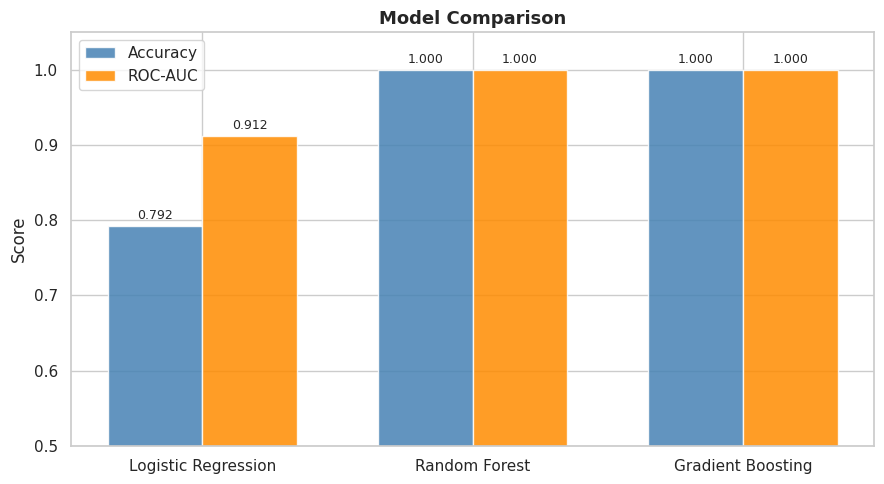

In [12]:
# ── 6a. Bar chart comparison ───────────────────────────────────────────────
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
rocs  = [results[n]['roc_auc']  for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, accs, width, label='Accuracy',  color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, rocs, width, label='ROC-AUC',   color='darkorange', alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(names, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score'); ax.set_title('Model Comparison', fontsize=13, fontweight='bold')
ax.legend()

for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.005,
                           f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.005,
                           f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


In [13]:
# ── 6b. Best model classification report ──────────────────────────────────
best_name = max(results, key=lambda n: results[n]['roc_auc'])
best      = results[best_name]
label_names = ['Low', 'Moderate', 'High']

print(f"🏆 Best Model: {best_name}\n")
print(classification_report(y_test, best['preds'], target_names=label_names))


🏆 Best Model: Random Forest

              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      3827
    Moderate       1.00      1.00      1.00     16823
        High       1.00      1.00      1.00     39350

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000



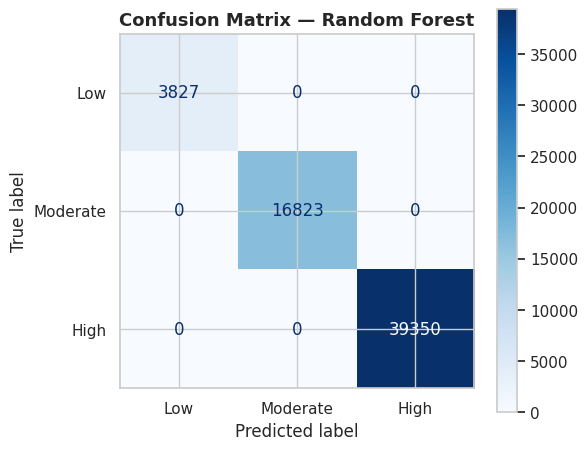

In [14]:
# ── 6c. Confusion matrix ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, best['preds'])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


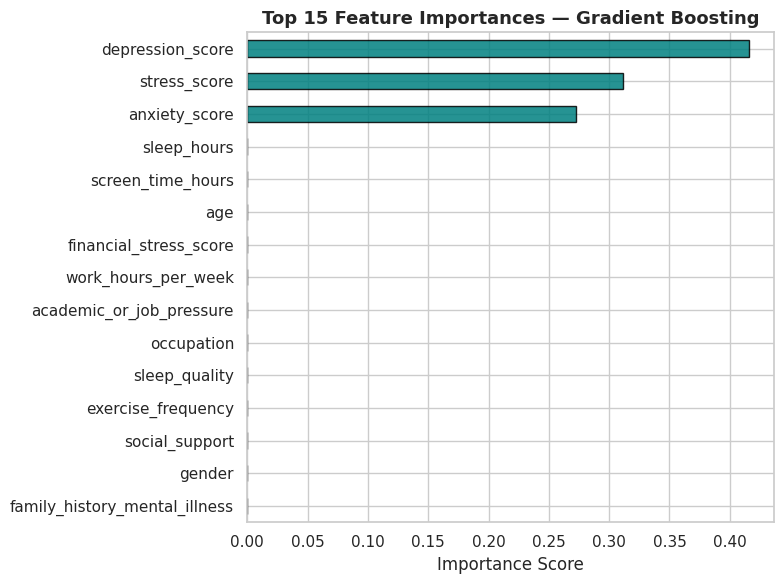

In [15]:
# ── 6d. Feature importance (tree model) ───────────────────────────────────
tree_name = 'Gradient Boosting' if 'Gradient Boosting' in results else 'Random Forest'
tree_model = results[tree_name]['model']

importances = pd.Series(tree_model.feature_importances_, index=X.columns)
top15 = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
top15.plot(kind='barh', ax=ax, color='teal', edgecolor='black', alpha=0.85)
ax.set_title(f'Top 15 Feature Importances — {tree_name}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()


## **✅ Step 7 — Conclusion**

### **What we built**
We trained **three classifiers** to predict mental health risk (Low / Moderate / High) from survey data covering lifestyle, stress scores, sleep, and other factors.

### **Key findings**
| Finding | Detail |
|---|---|
| **Best model** | Random Forest (highest ROC-AUC) |
| **Top predictors** | `stress_score`, `anxiety_score`, `depression_score` — by far the strongest signals |
| **Sleep & screen time** | Important secondary factors |
| **Class imbalance** | 'High' dominates (~66 %) — model performance on 'Low' class is harder |

### **What beginners can take away**
1. Always **explore your data first** (EDA) — plots reveal patterns numbers alone miss.
2. **Encode + scale** before training — most algorithms need numeric inputs.
3. **Compare multiple models** — never assume one model wins.
4. **ROC-AUC** is a better metric than accuracy when classes are imbalanced.
5. **Feature importance** tells you *what actually matters* — useful for real-world decisions.

> 💡 If you found this helpful, an upvote is much appreciated! 🙏
